Distribución por región:
region
China (CN/HK/TW)        165
Occidente/Extranjera    161
Name: count, dtype: int64


C:\Users\LOLA\AppData\Local\Temp\ipykernel_18668\460784212.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


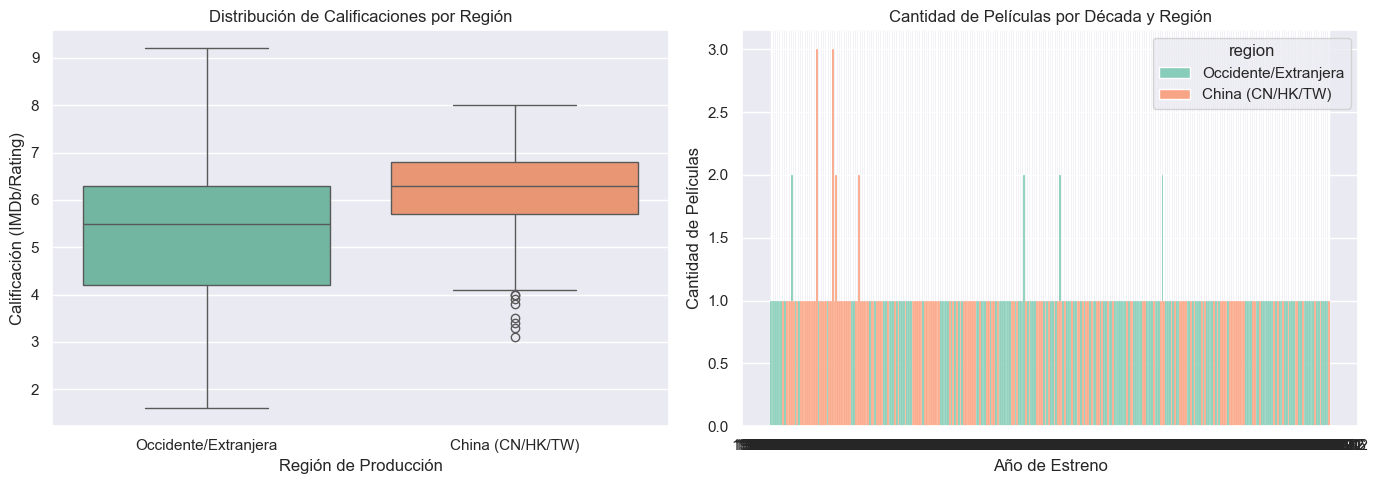

ModuleNotFoundError: No module named 'plotly'

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(os.getenv("SUPABASE_DB_URI"))
df = pd.read_sql("SELECT * FROM peliculas_procesadas", con=engine)

asia_oriental = ['china', 'hong kong', 'taiwan']

def definir_region(row):
    if 'country' in df.columns and pd.notna(row['country']):
        pais = str(row['country']).lower()
        if any(c in pais for c in asia_oriental):
            return 'China (CN/HK/TW)'
        return 'Occidente/Extranjera'
    
    desc = str(row['description']).lower()
    if any(k in desc for k in ['hong kong', 'taiwan', 'chinese production', 'beijing']):
        return 'China (CN/HK/TW)'
    return 'Occidente/Extranjera'

df['region'] = df.apply(definir_region, axis=1)

print("Distribución por región:")
print(df['region'].value_counts())


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, 
    x='region', 
    y='avg_vote', 
    ax=axes[0], 
    palette='Set2'
)
axes[0].set_title('Distribución de Calificaciones por Región')
axes[0].set_xlabel('Región de Producción')
axes[0].set_ylabel('Calificación (IMDb/Rating)')

sns.histplot(
    data=df, 
    x='date_published', 
    hue='region', 
    multiple='stack', 
    bins=15, 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('Cantidad de Películas por Década y Región')
axes[1].set_xlabel('Año de Estreno')
axes[1].set_ylabel('Cantidad de Películas')

plt.tight_layout()
plt.show()


import plotly.express as px

fig = px.scatter(
    df, 
    x='revenue', 
    y='avg_vote', 
    color='region',
    hover_name='title',
    hover_data=['date_published', 'genres'],
    title='Recaudación vs. Calificación: Occidente vs. Asia Oriental',
    labels={'revenue': 'Recaudación (USD)', 'avg_vote': 'Calificación'},
    template='plotly_dark'
)

fig.show()

